# EWS Fraud Detection - Tahap 7: Auditing Label dan Analisis Rule

Notebook ini bertujuan untuk melakukan auditing terhadap data EWS sebelum masuk ke tahap pemodelan machine learning.

Kita akan:
1. Mendefinisikan 5 aturan (rules) pendeteksian indikasi risiko fraud.
2. Menganalisis distribusi pemicuan masing-masing aturan untuk memastikan tidak ada aturan yang dominan secara bias.
3. Membuat dua versi label target lemah (**weak_label**):
   - **Threshold >= 3**: Emiten-tahun memicu minimal 3 aturan.
   - **Threshold >= 2**: Emiten-tahun memicu minimal 2 aturan.
4. Melakukan audit terhadap emiten mana saja yang tergolong High Risk berdasarkan kedua threshold tersebut.
5. Menyimpan laporan audit terpisah dalam format Excel.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set gaya visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Memuat Dataset Terintegrasi

In [2]:
dataset_path = "Final_EWS_Dataset.xlsx"

if os.path.exists(dataset_path):
    df = pd.read_excel(dataset_path)
    print(f"Dataset EWS berhasil dimuat. Dimensi: {df.shape}")
else:
    print("[ERROR] Berkas Final_EWS_Dataset.xlsx tidak ditemukan!")

Dataset EWS berhasil dimuat. Dimensi: (1637, 84)


## 2. Definisi & Evaluasi 5 Aturan Pendeteksian

In [15]:
# 1. Rule 1: M-Score Tinggi (Klasik Beneish Cutoff > -2.22)
rule1 = df['m_score'] > -2.22

# 2. Rule 2: Isolation Forest Outlier (anomaly_label_05 == -1)
rule2 = df['anomaly_label_05'] == -1

# 3. Rule 3: Narrative Risk Tinggi (narrative_risk_score > 60)
rule3 = df['narrative_risk_score'] > df['narrative_risk_score'].quantile(0.95)

# 4. Rule 4: CFO Quality Buruk (cfo_quality_flag == 'Low Quality')
rule4 = df['cfo_quality_flag'] == 'Low Quality'

# 5. Rule 5: Revenue Growth Ekstrem (revenue_growth > 95th Percentile)
rev_growth_95 = df['revenue_growth'].quantile(0.95)
rule5 = df['revenue_growth'] > rev_growth_95

### Pengecekan Distribusi Masing-Masing Rule
Kita akan memeriksa frekuensi pemicuan masing-masing aturan untuk mendeteksi apakah terdapat aturan yang dominan (mengendalikan label target secara sepihak).

=== Distribusi Pemicuan Aturan ===


,Rule,Trigger Count,Percentage (%)
0,Rule 1 (M-Score > -2.22),706,43.127673
1,Rule 2 (I-Forest Anomaly),82,5.009163
2,Rule 3 (Narrative Risk > P95),82,5.009163
3,Rule 4 (CFO Quality),455,27.794746
4,Rule 5 (Revenue Growth > P95),82,5.009163


C:\Users\MMASZZS123\AppData\Local\Temp\ipykernel_26728\2848865382.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_rules, x='Trigger Count', y='Rule', palette='viridis')


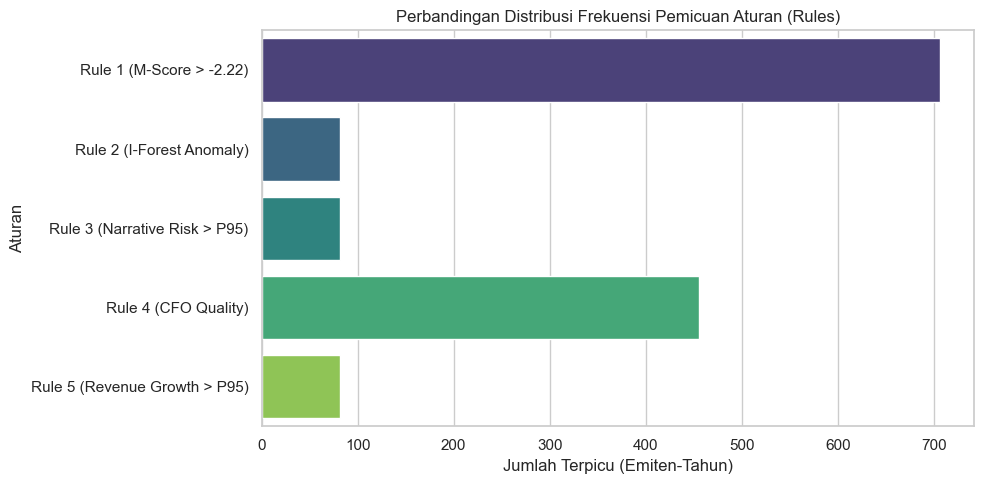

In [16]:
total_records = len(df)
rule_counts = {
    'Rule 1 (M-Score > -2.22)': rule1.sum(),
    'Rule 2 (I-Forest Anomaly)': rule2.sum(),
    'Rule 3 (Narrative Risk > P95)': rule3.sum(),
    'Rule 4 (CFO Quality)': rule4.sum(),
    'Rule 5 (Revenue Growth > P95)': rule5.sum()
}

df_rules = pd.DataFrame(list(rule_counts.items()), columns=['Rule', 'Trigger Count'])
df_rules['Percentage (%)'] = (df_rules['Trigger Count'] / total_records) * 100

print("=== Distribusi Pemicuan Aturan ===")
display(df_rules)

# Visualisasi
plt.figure(figsize=(10, 5))
sns.barplot(data=df_rules, x='Trigger Count', y='Rule', palette='viridis')
plt.title('Perbandingan Distribusi Frekuensi Pemicuan Aturan (Rules)')
plt.xlabel('Jumlah Terpicu (Emiten-Tahun)')
plt.ylabel('Aturan')
plt.tight_layout()
plt.show()

                         Rule 1 (M-Score)  Rule 2 (I-Forest)  \
Rule 1 (M-Score)                 1.000000           0.173229   
Rule 2 (I-Forest)                0.173229           1.000000   
Rule 3 (Narrative Risk)          0.037520           0.049973   
Rule 4 (CFO Quality)             0.338023          -0.023703   
Rule 5 (Revenue Growth)          0.195848           0.383766   

                         Rule 3 (Narrative Risk)  Rule 4 (CFO Quality)  \
Rule 1 (M-Score)                        0.037520              0.338023   
Rule 2 (I-Forest)                       0.049973             -0.023703   
Rule 3 (Narrative Risk)                 1.000000              0.032558   
Rule 4 (CFO Quality)                    0.032558              1.000000   
Rule 5 (Revenue Growth)                 0.049973             -0.029954   

                         Rule 5 (Revenue Growth)  
Rule 1 (M-Score)                        0.195848  
Rule 2 (I-Forest)                       0.383766  
Rule 3 (Narrative

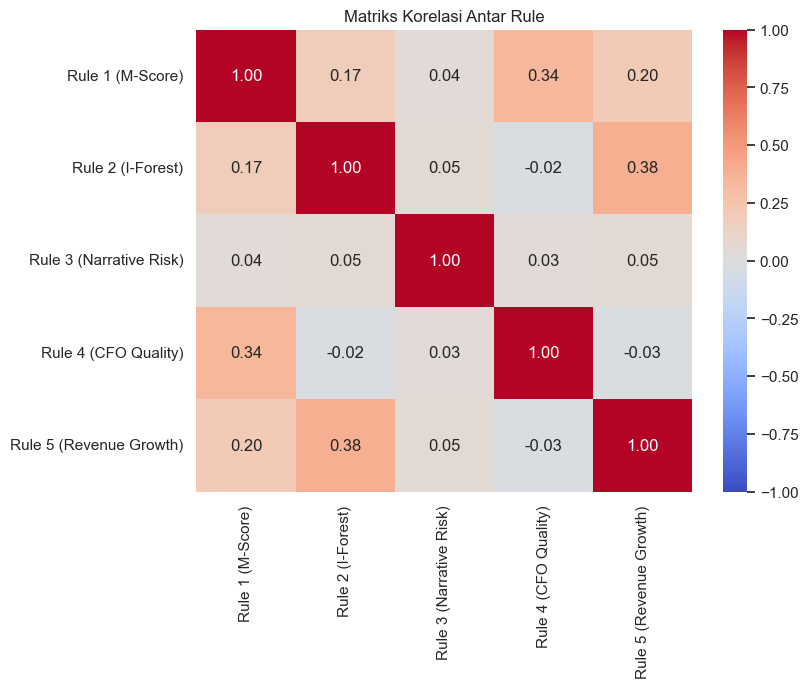

In [17]:
df_corr_matrix = pd.DataFrame({
    'Rule 1 (M-Score)': rule1,
    'Rule 2 (I-Forest)': rule2,
    'Rule 3 (Narrative Risk)': rule3,
    'Rule 4 (CFO Quality)': rule4,
    'Rule 5 (Revenue Growth)': rule5
})

korelasi = df_corr_matrix.corr(method='pearson')

print(korelasi)

plt.figure(figsize=(8, 6))
sns.heatmap(korelasi, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Matriks Korelasi Antar Rule')
plt.show()

In [14]:
df["narrative_risk_score"].describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

count    1637.000000
mean       25.103370
std         5.929787
min         0.036798
50%        24.468686
75%        28.261339
90%        32.134614
95%        34.796981
99%        42.533983
max        62.524446
Name: narrative_risk_score, dtype: float64

## 3. Penghitungan Weak Score & Perbandingan Threshold (>= 2 vs >= 3)

In [18]:
# Menghitung jumlah rule terpicu per emiten-tahun
df['weak_score'] = rule1.astype(int) + rule2.astype(int) + rule3.astype(int) + rule4.astype(int) + rule5.astype(int)

# Threshold >= 3
df['weak_label_t3'] = (df['weak_score'] >= 3).astype(int)

# Threshold >= 2
df['weak_label_t2'] = (df['weak_score'] >= 2).astype(int)

=== Distribusi Jumlah Aturan Terpicu (Weak Score) ===
weak_score
0    740
1    476
2    343
3     69
4      7
5      2
Name: count, dtype: int64

=== Perbandingan Distribusi Target Weak Label ===
Threshold >= 3 (High Risk): 78 records (4.76%)
Threshold >= 2 (High Risk): 421 records (25.72%)


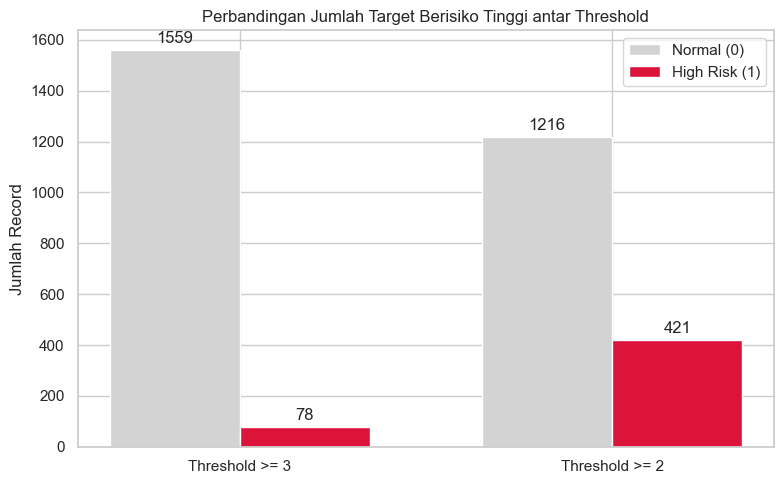

In [19]:
print("=== Distribusi Jumlah Aturan Terpicu (Weak Score) ===")
print(df['weak_score'].value_counts().sort_index())

print("\n=== Perbandingan Distribusi Target Weak Label ===")
print(f"Threshold >= 3 (High Risk): {df['weak_label_t3'].sum()} records ({(df['weak_label_t3'].sum()/total_records)*100:.2f}%)")
print(f"Threshold >= 2 (High Risk): {df['weak_label_t2'].sum()} records ({(df['weak_label_t2'].sum()/total_records)*100:.2f}%)")

# Visualisasi Perbandingan
labels = ['Threshold >= 3', 'Threshold >= 2']
high_risk_counts = [df['weak_label_t3'].sum(), df['weak_label_t2'].sum()]
normal_counts = [total_records - df['weak_label_t3'].sum(), total_records - df['weak_label_t2'].sum()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, normal_counts, width, label='Normal (0)', color='lightgrey')
rects2 = ax.bar(x + width/2, high_risk_counts, width, label='High Risk (1)', color='crimson')

ax.set_ylabel('Jumlah Record')
ax.set_title('Perbandingan Jumlah Target Berisiko Tinggi antar Threshold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for r in rects1 + rects2:
    h = r.get_height()
    ax.annotate(f'{h}',
                xy=(r.get_x() + r.get_width() / 2, h),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 4. Auditing Emiten Teridentifikasi (High Risk)

In [20]:
# Kolom-kolom kunci untuk keperluan audit
audit_cols = [
    'kode', 'tahun', 'Nama Perusahaan', 'Sektor',
    'm_score', 'anomaly_label_05', 'narrative_risk_score',
    'cfo_quality_flag', 'revenue_growth', 'weak_score'
]

### A. Audit Versi Threshold >= 3

In [21]:
df_audit_t3 = df[df['weak_label_t3'] == 1][audit_cols].sort_values(by='weak_score', ascending=False)
print(f"=== Daftar Emiten Tergolong High Risk (Threshold >= 3) | Total: {len(df_audit_t3)} ===")
display(df_audit_t3.head(20))

# Simpan Laporan Audit T3
t3_output_path = "Fraud_Audit_Report_T3.xlsx"
df_audit_t3.to_excel(t3_output_path, index=False)
print(f"Laporan Audit T3 disimpan ke: {t3_output_path}")

=== Daftar Emiten Tergolong High Risk (Threshold >= 3) | Total: 78 ===


,kode,tahun,Nama Perusahaan,Sektor,m_score,anomaly_label_05,narrative_risk_score,cfo_quality_flag,revenue_growth,weak_score
1125,PKPK,2024,Paragon Karya Perkasa Tbk.,Energy,1.670058,-1,38.080376,Low Quality,3.234716,5
1263,RUNS,2022,Global Sukses Solusi Tbk.,Technology,1.074152,-1,35.204447,Low Quality,5.338355,5
504,FIRE,2024,Alfa Energi Investama Tbk.,Energy,-1.382692,1,48.242995,Low Quality,0.892633,4
724,ISAP,2023,PT Isra Presisi Indonesia Tbk,Consumer Cyclicals,0.790774,-1,22.739845,Low Quality,2.671107,4
1223,PYFA,2024,PT Pyridam Farma Tbk,Healthcare,1.138691,-1,36.084709,Normal,1.735936,4
1083,PANR,2022,Panorama Sentrawisata Tbk.,Consumer Cyclicals,4.521655,-1,37.736794,Normal,7.599894,4
864,LCKM,2024,LCK Global Kedaton Tbk.,Infrastructure,1.080588,-1,38.439585,Low Quality,0.296548,4
925,MBSS,2024,Mitrabahtera Segara Sejati Tbk.,Energy,6.225572,-1,22.000000,Low Quality,7.599894,4
1574,WAPO,2024,Wahana Pronatural Tbk,Consumer Non-Cyclicals,1.603399,-1,26.002429,Low Quality,4.041718,4
54,ALKA,2023,Alakasa Industrindo Tbk,Basic Material,1.627707,-1,24.756049,Low Quality,-0.542284,3


Laporan Audit T3 disimpan ke: Fraud_Audit_Report_T3.xlsx


### B. Audit Versi Threshold >= 2

In [22]:
df_audit_t2 = df[df['weak_label_t2'] == 1][audit_cols].sort_values(by='weak_score', ascending=False)
print(f"=== Daftar Emiten Tergolong High Risk (Threshold >= 2) | Total: {len(df_audit_t2)} ===")
display(df_audit_t2.head(20))

# Simpan Laporan Audit T2
t2_output_path = "Fraud_Audit_Report_T2.xlsx"
df_audit_t2.to_excel(t2_output_path, index=False)
print(f"Laporan Audit T2 disimpan ke: {t2_output_path}")

=== Daftar Emiten Tergolong High Risk (Threshold >= 2) | Total: 421 ===


,kode,tahun,Nama Perusahaan,Sektor,m_score,anomaly_label_05,narrative_risk_score,cfo_quality_flag,revenue_growth,weak_score
1263,RUNS,2022,Global Sukses Solusi Tbk.,Technology,1.074152,-1,35.204447,Low Quality,5.338355,5
1125,PKPK,2024,Paragon Karya Perkasa Tbk.,Energy,1.670058,-1,38.080376,Low Quality,3.234716,5
1574,WAPO,2024,Wahana Pronatural Tbk,Consumer Non-Cyclicals,1.603399,-1,26.002429,Low Quality,4.041718,4
1083,PANR,2022,Panorama Sentrawisata Tbk.,Consumer Cyclicals,4.521655,-1,37.736794,Normal,7.599894,4
1223,PYFA,2024,PT Pyridam Farma Tbk,Healthcare,1.138691,-1,36.084709,Normal,1.735936,4
724,ISAP,2023,PT Isra Presisi Indonesia Tbk,Consumer Cyclicals,0.790774,-1,22.739845,Low Quality,2.671107,4
864,LCKM,2024,LCK Global Kedaton Tbk.,Infrastructure,1.080588,-1,38.439585,Low Quality,0.296548,4
925,MBSS,2024,Mitrabahtera Segara Sejati Tbk.,Energy,6.225572,-1,22.000000,Low Quality,7.599894,4
504,FIRE,2024,Alfa Energi Investama Tbk.,Energy,-1.382692,1,48.242995,Low Quality,0.892633,4
54,ALKA,2023,Alakasa Industrindo Tbk,Basic Material,1.627707,-1,24.756049,Low Quality,-0.542284,3


Laporan Audit T2 disimpan ke: Fraud_Audit_Report_T2.xlsx


## 5. Penyimpanan Dataset EWS Ter-update

In [23]:
# Hapus kolom prediksi XGBoost lama jika ada (untuk menjaga kemurnian dataset pra-pemodelan)
cols_to_drop = ['xgboost_fraud_prob', 'xgboost_fraud_pred']
df_clean = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# Simpan kembali Final_EWS_Dataset.xlsx
df_clean.to_excel("Final_EWS_Dataset.xlsx", index=False)
print(f"Dataset Final_EWS_Dataset.xlsx berhasil diperbarui dengan weak target columns. Dimensi akhir: {df_clean.shape}")

Dataset Final_EWS_Dataset.xlsx berhasil diperbarui dengan weak target columns. Dimensi akhir: (1637, 84)
